In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

Наша задача будет обучить модель предсказывать класс цены автомобиля

Y - price_category

In [2]:
df = pd.read_csv('/content/vehicles_dataset_prepared.csv')

In [3]:
df.head()

,id,price,price_category,is_audi,is_ford,is_chevrolet,is_toyota,x0_diesel,x0_electric,x0_gas,...,long_std,year_std,odometer/price_std,desc_len_std,model_in_desc_std,model_len_std,model_word_count_std,month_std,dayofweek_std,diff_years_std
0,7308295377,54990,high,0,0,0,0,1.0,0.0,0.0,...,0.484245,1.322394,-0.510784,0.632075,-0.155788,1.163032,1.910669,-0.615846,1.120284,-1.322394
1,7316380095,16942,medium,0,1,0,0,0.0,0.0,0.0,...,1.110800,0.695973,-0.402947,-0.646781,-0.155788,0.932087,1.235799,1.623784,-1.374972,-0.695973
2,7313733749,35590,high,0,0,0,0,0.0,0.0,1.0,...,0.531185,0.852578,-0.514480,0.560744,-0.155788,0.470197,0.560930,-0.615846,-0.376870,-0.852578
3,7308210929,14500,medium,0,0,0,1,0.0,0.0,1.0,...,0.853562,0.226157,-0.241883,0.180435,-0.155788,-0.915473,-0.788810,-0.615846,1.120284,-0.226157
4,7303797340,14590,medium,0,0,0,0,0.0,0.0,0.0,...,0.557607,0.069552,-0.333074,0.766366,-0.155788,1.163032,1.910669,-0.615846,0.122182,-0.069552


In [4]:
df.price_category.value_counts()

,count
price_category,
low,1068
high,1051
medium,1001


Классы сбалансированны ✅

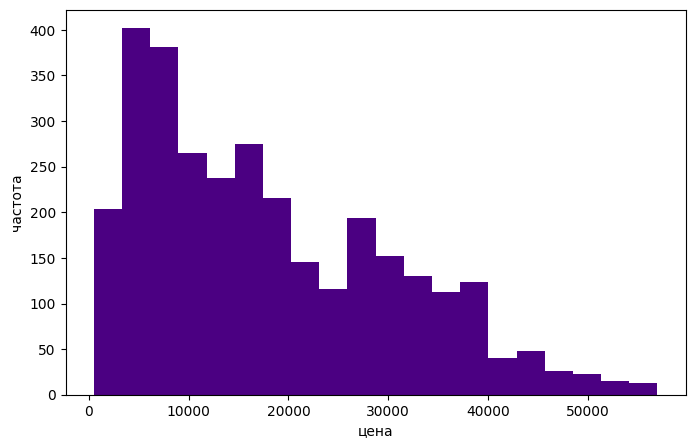

In [9]:
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(df.price, color='indigo', bins=20)
ax.set_xlabel('цена')
ax.set_ylabel('частота')
plt.show();

In [11]:
df.columns

Index(['id', 'price', 'price_category', 'is_audi', 'is_ford', 'is_chevrolet',
       'is_toyota', 'x0_diesel', 'x0_electric', 'x0_gas',
       ...
       'long_std', 'year_std', 'odometer/price_std', 'desc_len_std',
       'model_in_desc_std', 'model_len_std', 'model_word_count_std',
       'month_std', 'dayofweek_std', 'diff_years_std'],
      dtype='object', length=1463)

In [12]:
df_prepared = df.copy()

In [21]:
x = df_prepared.drop(['price_category'], axis=1)
y = df_prepared.price_category

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [25]:
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)

DecisionTreeClassifier()

In [27]:
predicted_train = clf.predict(x_train)
predicted_test = clf.predict(x_test)

In [28]:
predicted_train

array(['high', 'high', 'medium', ..., 'medium', 'medium', 'high'],
      dtype=object)

In [29]:
predicted_test

array(['high', 'high', 'medium', 'low', 'medium', 'medium', 'medium',
       'medium', 'medium', 'high', 'medium', 'medium', 'low', 'medium',
       'high', 'low', 'low', 'high', 'medium', 'high', 'high', 'medium',
       'medium', 'medium', 'medium', 'medium', 'low', 'high', 'medium',
       'high', 'medium', 'low', 'medium', 'high', 'medium', 'medium',
       'low', 'low', 'medium', 'low', 'high', 'high', 'low', 'medium',
       'medium', 'low', 'high', 'high', 'high', 'high', 'medium', 'high',
       'medium', 'low', 'low', 'high', 'medium', 'low', 'medium',
       'medium', 'high', 'low', 'high', 'low', 'medium', 'high', 'high',
       'medium', 'medium', 'low', 'low', 'high', 'medium', 'high',
       'medium', 'medium', 'high', 'high', 'high', 'high', 'low',
       'medium', 'low', 'medium', 'high', 'low', 'high', 'high', 'medium',
       'low', 'low', 'medium', 'low', 'high', 'medium', 'low', 'medium',
       'high', 'low', 'high', 'high', 'high', 'low', 'high', 'low', 'low',
   

In [32]:
accuracy_score(y_train, predicted_train)

1.0

In [33]:
accuracy_score(y_test, predicted_test)

0.9989316239316239

Модель переобучилась, проблема в data leakage. Модель подсматривала значения из колонок 'price' и 'odometer/price_std'. Нужно удалить эти колонки и провести моделирование ещё раз

In [34]:
df_prepared = df_prepared.drop(['price', 'odometer/price_std'], axis=1)

In [36]:
x = df_prepared.drop(['price_category'], axis=1)
y = df_prepared.price_category

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)

predicted_train = clf.predict(x_train)
predicted_test = clf.predict(x_test)

In [37]:
accuracy_score(y_train, predicted_train)

1.0

In [38]:
accuracy_score(y_test, predicted_test)

0.6485042735042735

In [40]:
#посмотрим веса
clf.feature_importances_

array([0.03430929, 0.        , 0.00500876, ..., 0.00264182, 0.01223598,
       0.0359737 ])

In [41]:
f_imp_list = list(zip(x_train.columns, clf.feature_importances_))
f_imp_list.sort(key=lambda x: x[1], reverse=True)

In [43]:
f_imp_list[:5]

[('year_std', np.float64(0.19337661405264717)),
 ('std_scaled_odometer', np.float64(0.12584140761553844)),
 ('desc_len_std', np.float64(0.08245035739085119)),
 ('lat_std', np.float64(0.05326300403754432)),
 ('diff_years_std', np.float64(0.03597369993295827))]